In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [45]:
# --- Define the ODEs for both cases ---
def case_a(t, y, omega0, Omega0):
  # In this case, y = [a1_real, a1_imag, a2_real, a2_imag] (a1 and a2 have real and imaginary parts)
  a1 = y[0] + 1j*y[1]
  a2 = y[2] + 1j*y[3]

  da1 = 1j*omega0/2*a1 - 1j*Omega0*a2
  da2 = -1j*omega0/2*a2 - 1j*Omega0*a1

  return [da1.real, da1.imag, da2.real, da2.imag]

def case_b(t, y, Omega0, omega):
  # In this case, y = [a1_real, a1_imag, a2_real, a2_imag] (a1 and a2 have real and imaginary parts)
  a1 = y[0] + 1j*y[1]
  a2 = y[2] + 1j*y[3]

  da1 = -1j*Omega0*np.cos(omega*t)*a2
  da2 = -1j*Omega0*np.cos(omega*t)*a1

  return [da1.real, da1.imag, da2.real, da2.imag]

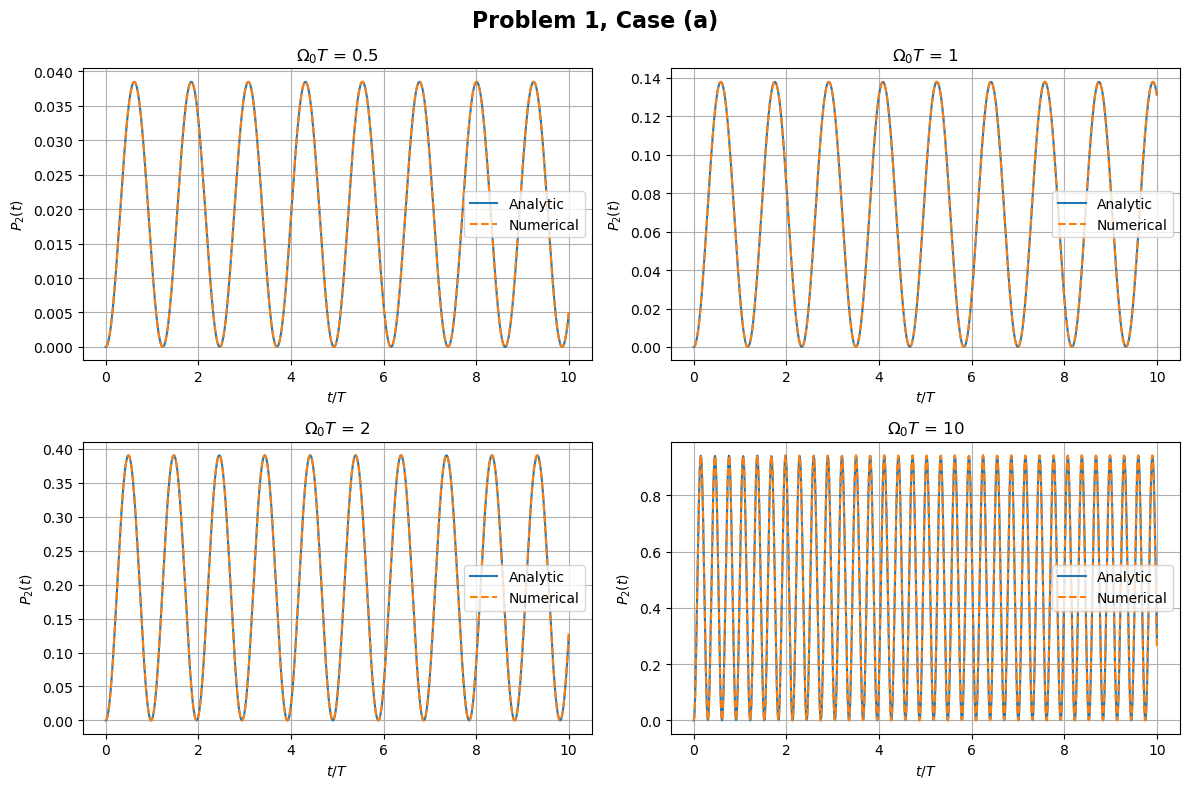

In [60]:
# --- Define initial conditions: ---
y0 = [1.0, 0.0, 0.0, 0.0]  # a1(0) = 1, a2(0) = 0

# --- Define the parameters for case (a): ---
omega0 = 5.0
Omega0_arr = [0.5, 1, 2, 10]

t_span = (0, 10) 
t_eval = np.linspace(*t_span, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, Omega0 in enumerate(Omega0_arr):
  ax = axes[i]

  # --- Analytic solution ---
  OmegaR = np.sqrt(omega0**2 + 4*Omega0**2)
  a2_analytic = -1j*(2*Omega0/OmegaR)*np.sin(OmegaR*t_eval/2)
  P2_analytic = np.abs(a2_analytic)**2
  ax.plot(t_eval, P2_analytic, '-', label='Analytic')

  # --- Solve numerically ---
  sol = solve_ivp(case_a, t_span, y0, t_eval=t_eval, args=(omega0, Omega0))
  a2_num = sol.y[2] + 1j*sol.y[3]        # complex amplitude
  P2_num = np.abs(a2_num)**2             # numerical population
  ax.plot(t_eval, P2_num, '--', label='Numerical')

  ax.set_title(rf'$\Omega_0 T$ = {Omega0}')
  ax.set_xlabel(r'$t/T$')
  ax.set_ylabel(r'$P_2(t)$')
  ax.legend(loc='center right')
  ax.grid(True)

fig.suptitle("Problem 1, Case (a)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

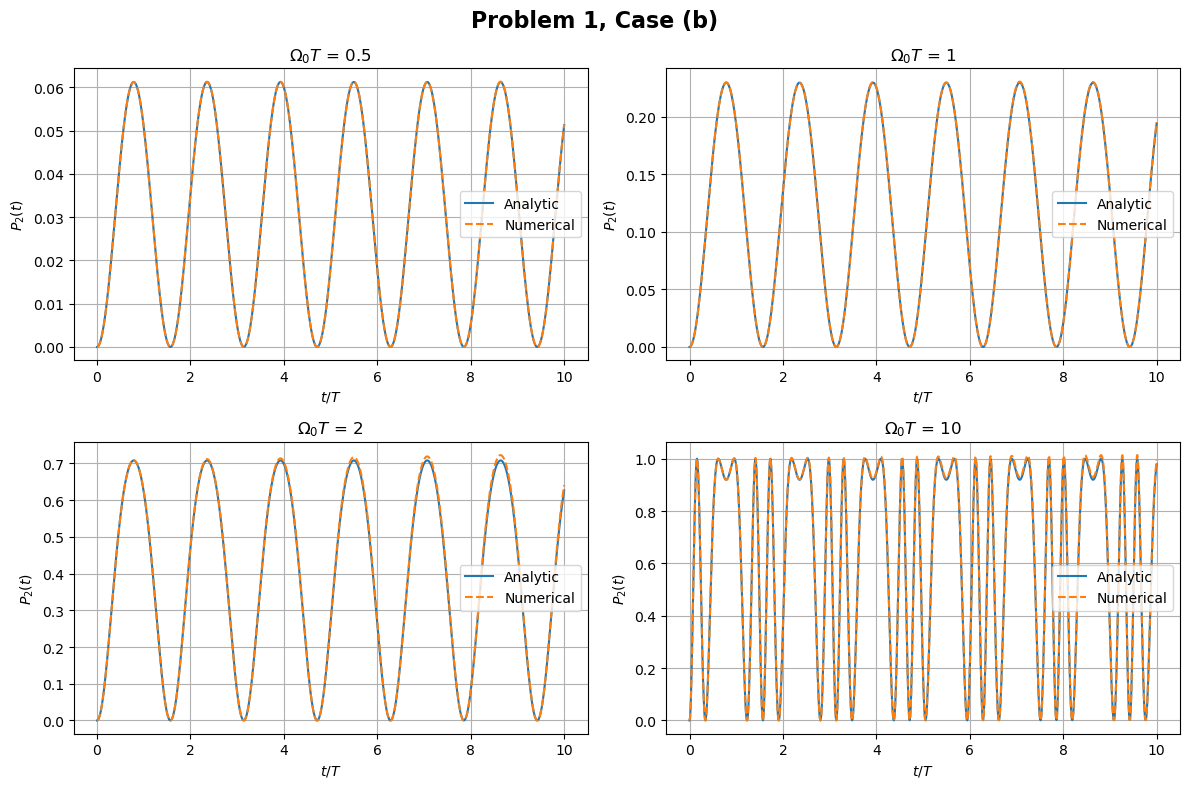

In [61]:
# --- Define initial conditions: ---
y0 = [1.0, 0.0, 0.0, 0.0]  # a1(0) = 1, a2(0) = 0

# --- Define the parameters for case (b): ---
omega = 2.0
Omega0_arr = [0.5, 1, 2, 10]

t_span = (0, 10) 
t_eval = np.linspace(*t_span, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, Omega0 in enumerate(Omega0_arr):
  ax = axes[i]

  # --- Analytic solution ---
  P2_analytic = np.sin((Omega0 / omega) * np.sin(omega * t_eval))**2
  ax.plot(t_eval, P2_analytic, '-', label='Analytic')

  # --- Numerical solution ---
  sol = solve_ivp(case_b, t_span, y0, t_eval=t_eval, args=(Omega0, omega))
  a2_num = sol.y[2] + 1j*sol.y[3]
  P2_num = np.abs(a2_num)**2
  ax.plot(t_eval, P2_num, '--', label='Numerical')

  ax.set_title(rf'$\Omega_0 T$ = {Omega0}')
  ax.set_xlabel(r'$t/T$')
  ax.set_ylabel(r'$P_2(t)$')
  ax.legend(loc='center right')
  ax.grid(True)

fig.suptitle("Problem 1, Case (b)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## PROBLEM 3:

In [62]:
# --- Define the ODE and detuning function ---
OmegaT = 30.0

def detuning(tau):
  if tau < 0:
    return 30 * (1 - np.exp(tau))**3
  else:
    return 0.0

def ode(tau, y):
  x1, y1, x2, y2 = y

  c1 = x1 + 1j*y1
  c2 = x2 + 1j*y2

  deltaT = detuning(tau)
  coupling = OmegaT * np.exp(-tau**2)

  dc1 = 0.5j*deltaT*c1 - 0.5j*coupling*c2
  dc2 = -0.5j*deltaT*c2 - 0.5j*coupling*c1

  return [dc1.real, dc1.imag, dc2.real, dc2.imag]

In [63]:
y0 = [1.0, 0.0, 0.0, 0.0]  # c1 = 1, c2 = 0

tau_span = (-6, 6)
tau_eval = np.linspace(-6, 6, 2000)

sol = solve_ivp(ode, tau_span, y0, t_eval=tau_eval)

In [65]:
x1, y1, x2, y2 = sol.y

c1 = x1 + 1j*y1
c2 = x2 + 1j*y2

P2 = np.abs(c2)**2
P1 = np.abs(c1)**2

rho12 = np.abs(c1 * np.conj(c2))

# Pulse envelope
Omega_tau = OmegaT * np.exp(-tau_eval**2)

# Detuning function for all tau_eval points
delta_tau_array = np.array([detuning(tau) for tau in tau_eval])

# Coherence
rho12_adiabatic = Omega_tau / (2 * np.sqrt(Omega_tau**2 + delta_tau_array**2))

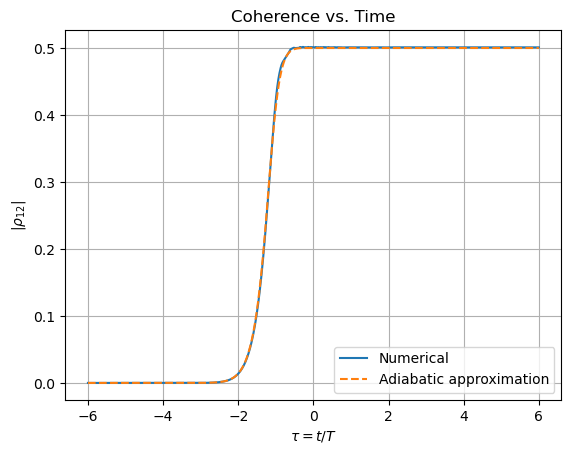

In [66]:
plt.plot(tau_eval, rho12, label='Numerical')
plt.plot(tau_eval, rho12_adiabatic, '--', label='Adiabatic approximation')
plt.xlabel(r'$\tau = t/T$')
plt.ylabel(r'$|\rho_{12}|$')
plt.title('Coherence vs. Time')
plt.legend()
plt.grid()
plt.show()

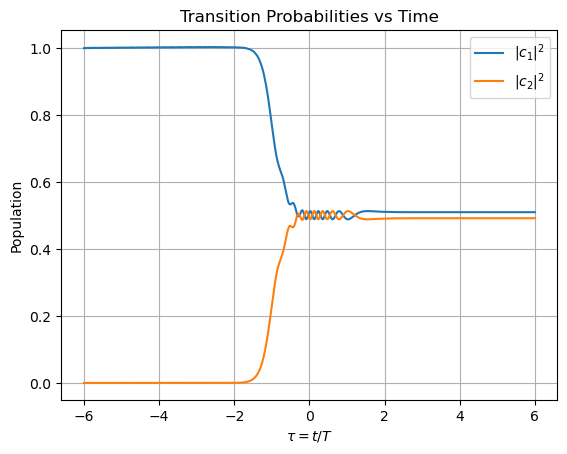

In [67]:
plt.figure()
plt.plot(tau_eval, P1, label=r'$|c_1|^2$')
plt.plot(tau_eval, P2, label=r'$|c_2|^2$')
plt.xlabel(r'$\tau = t/T$')
plt.ylabel('Population')
plt.title('Transition Probabilities vs Time')
plt.legend()
plt.grid()
plt.show()